# Possibilistic Portfolio Optimisation — Exposition & Results

This notebook documents the design and empirical performance of a **possibilistic model-averaging**
framework for dynamic portfolio construction. The framework replaces the standard probabilistic
normalisation constant (sum / integral) with a **supremum**, producing possibility distributions
that are more transparent about epistemic uncertainty.

**Datasets:** 20 Kenneth French daily portfolio series (1980–2026, ~11,600 trading days)  
**Algorithms:** Bayesian MA (baseline), Possibilistic MA (masked / power / exponential necessity weighting)
+ classical benchmarks (1/N, Market)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

RESULTS_DIR   = Path('results')
SIM_FOLDERS   = {'iid', 'break', 'mr', 'reg', 'cov_break', 'stoch_vol'}
SMOOTH_WINDOW = 21
COV_WINDOW    = 252
SHARPE_WINDOW = 252

DATASET_LABELS = {
    '10_Industry_Portfolios_Daily_equal_weighted':        'Industry (EW)',
    '10_Industry_Portfolios_Daily_value_weighted':        'Industry (VW)',
    '10_Portfolios_Formed_on_ME_size_equal_weighted':     'Size (EW)',
    '10_Portfolios_Formed_on_ME_size_value_weighted':     'Size (VW)',
    '10_Portfolios_Formed_on_booktomarket_equal_weighted':'B/M (EW)',
    '10_Portfolios_Formed_on_booktomarket_value_weighted':'B/M (VW)',
    '10_Portfolios_Prior_momentum_equal_weighted':        'Momentum (EW)',
    '10_Portfolios_Prior_momentum_value_weighted':        'Momentum (VW)',
    '10_Portfolios_Prior_str_equal_weighted':             'ST Rev. (EW)',
    '10_Portfolios_Prior_str_value_weighted':             'ST Rev. (VW)',
    '10_Portfolios_ltr_equal_weighted':                   'LT Rev. (EW)',
    '10_Portfolios_ltr_value_weighted':                   'LT Rev. (VW)',
    '6_Portfolios_size_btm_equal_weighted':               'Size*B/M (EW)',
    '6_Portfolios_size_btm_value_weighted':               'Size*B/M (VW)',
    '6_Portfolios_size_ltr_equal_weighted':               'Size*LTR (EW)',
    '6_Portfolios_size_ltr_value_weighted':               'Size*LTR (VW)',
    '6_Portfolios_size_momentum_equal_weighted':          'Size*Mom (EW)',
    '6_Portfolios_size_momentum_value_weighted':          'Size*Mom (VW)',
    '6_Portfolios_size_str_equal_weighted':               'Size*STR (EW)',
    '6_Portfolios_size_str_value_weighted':               'Size*STR (VW)',
}


STRATEGY_LABELS = {
    'bayesian_averaging':   'BMA',
    'possibilistic_masked': 'Poss. Masked',
    'possibilistic_power':  'Poss. Power',
    'possibilistic_exp':    'Poss. Exp',
    'equal_weight':         '1/N',
    'market_weight':        'Market',
}

FOCUS_STEMS = [
    'bayesian_averaging', 'possibilistic_masked', 'possibilistic_power', 'possibilistic_exp',
    'equal_weight', 'market_weight',
]
MODEL_STEMS = ['bayesian_averaging', 'possibilistic_masked', 'possibilistic_power', 'possibilistic_exp']

MODEL_COLORS = {
    'bayesian_averaging':   '#5aab61',
    'possibilistic_masked': '#e07b39',
    'possibilistic_power':  '#5b8db8',
    'possibilistic_exp':    '#e74c3c',
}
MODEL_COLOR_LIST = ['#5aab61', '#e07b39', '#5b8db8', '#e74c3c']
ACTUAL_STYLE = dict(color='#999999', lw=1.0, alpha=0.5, ls='--', zorder=1)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

In [45]:
all_folders  = sorted([f for f in RESULTS_DIR.iterdir() if f.is_dir()])
real_folders = [f for f in all_folders if f.name not in SIM_FOLDERS]

all_scalars = {}
for folder in all_folders:
    p = folder / 'scalars.csv'
    if p.exists():
        all_scalars[folder.name] = pd.read_csv(p, index_col=0)

print(f'Real-world datasets : {len(real_folders)}')
print(f'Folders with scalars: {len(all_scalars)}')

Real-world datasets : 20
Folders with scalars: 26


---
## 1  Possibility Theory and Epistemic Uncertainty

Standard Bayesian inference represents *all* uncertainty as probability, conflating two conceptually
distinct forms:

- **Aleatory uncertainty** — irreducible randomness inherent in the world
- **Epistemic uncertainty** — uncertainty due to limited information, model inadequacy, or small samples

When a prior is diffuse and the sample is small, Bayesian posterior beliefs can still concentrate
sharply — creating an illusion of knowledge. This is particularly dangerous in portfolio construction,
where overconfident estimates of expected returns drive extreme, unstable weights.

**Possibility theory** offers an alternative framework that is
transparent about ignorance:

| Concept | Definition | Interpretation |
|---------|-----------|----------------|
| Possibility measure | $\Pi(A) = \sup_{\omega \in A} \pi(\omega)$ | How consistent is $A$ with our knowledge? |
| Necessity measure | $N(A) = 1 - \Pi(\bar{A})$ | How robustly does evidence imply $A$? |

Key properties:
- $\pi$ is **max-normalised**: there exists $\omega$ with $\pi(\omega) = 1$ (at least one scenario is fully possible)
- $N(A) = 1$ means $A$ is certain; $N(A) = 0$ means $A$ is *not robustly implied* — consistent with
  complete ignorance, not evidence against $A$
- Unlike probability, $\Pi(A) + \Pi(\bar{A}) \geq 1$: both $A$ and its complement can be fully possible

**The possibilistic Bayes rule** replaces the probabilistic normalisation integral with a supremum:

$$\pi(\theta \mid x) = \frac{\pi(\theta) \cdot \ell(\theta; x)}{\sup_{\theta'} \big[\pi(\theta') \cdot \ell(\theta'; x)\big]}$$

This preserves the relative ranking of parameter values but prevents the denominator from
redistributing mass away from plausible regions — keeping models alive that a probabilistic
normalisation would render negligible.

In [46]:
rows = []
for folder in real_folders:
    ret = pd.read_csv(folder / 'returns.csv', index_col=0)
    rows.append({
        'Dataset': DATASET_LABELS.get(folder.name, folder.name),
        'Assets': ret.shape[1],
        'Trading days': ret.shape[0],
        'Avg daily return': ret.values.mean().round(5),
        'Avg daily vol': ret.values.std().round(5),
    })

overview = pd.DataFrame(rows)
print(f'Kenneth French daily portfolios — {len(overview)} datasets')
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 50):
    display(overview.style.hide(axis='index'))

Kenneth French daily portfolios — 20 datasets


Dataset,Assets,Trading days,Avg daily return,Avg daily vol
Industry (EW),11,11615,0.000580,0.012260
Industry (VW),11,11615,0.000370,0.012700
Size (EW),11,11615,0.000450,0.012230
Size (VW),11,11615,0.000370,0.011970
B/M (EW),11,11615,0.000630,0.011110
B/M (VW),11,11615,0.000390,0.011910
Momentum (EW),11,11615,0.000610,0.010940
Momentum (VW),11,11615,0.000350,0.013010
ST Rev. (EW),11,11615,0.000410,0.011240
ST Rev. (VW),11,11615,0.000400,0.012950


---
## 2  Bayesian Model Averaging over NIW Models

The **probabilistic baseline** maintains a pool of Normal-Inverse-Wishart (NIW) models.
Each model $m$ is characterised by hyperparameters $(\mu_0^m, \kappa_m, \Lambda_m, \nu_m)$,
which parametrise a conjugate prior over $(\mu, \Sigma)$.

**At each time step $t$:**

1. **New model entry**: a new NIW model with the sharing prior ($\alpha = 1$) is added
2. **Likelihood update**: each model's NIW hyperparameters are updated with $x_t$ via the
   conjugate closed-form update
3. **Weight update** (BMA): $p_t(m) \propto p_{t-1}(m) \cdot p(x_t \mid m)$, renormalised to sum to 1
4. **Pruning & merging**: models with $p_t(m) < \epsilon$ are dropped; models with similar
   hyperparameters are merged to control pool size
5. **Predictive moments**: arithmetic BMA —
   $\hat{\mu}_t = \sum_m p_t(m) \, \mu_t^m$, $\quad \hat{\Sigma}_t = \sum_m p_t(m) \, \Sigma_t^m$
6. **Markowitz weights**: $w_t^* = \arg\min_w \, w^\top \hat{\Sigma}_t w - \delta^{-1} w^\top \hat{\mu}_t$

The result is an adaptive, tractable Gaussian predictive that smoothly combines evidence
from all models weighted by their marginal likelihoods.

---
## 3  Possibilistic Extension

The possibilistic engine replaces the probabilistic weight update with the possibilistic Bayes rule:

$$\pi_t(m) = \frac{\pi_{t-1}(m) \cdot \ell_t(m)}{\sup_{m'} \big[\pi_{t-1}(m') \cdot \ell_t(m')\big]}$$

**Key differences from BMA:**

| Property | BMA (probabilistic) | Possibilistic MA |
|----------|--------------------|-----------------|
| Normalisation | Sum = 1 | Max = 1 |
| Response to new data | Redistributes mass | Scales relative to best model |
| Predictive aggregation | Arithmetic average | Geometric intersection |

**Consequence for portfolios**: because the possibility distribution retains more model diversity,
the predictive moments change more smoothly over time, leading to substantially lower turnover.

While the within model NIW parameter updates remain the same, we differ in terms of the across model possibility updates, and aggregation of the predictive mean and covariance.

Since we use a fucntion formed from both the possibility and necessity of a function, we can not only measure how good models are relative to each other, but also with respect to the new data observed.

---
## 4  Necessity Scores and Internal Validity

Each NIW model $m$ in the pool is assigned an **internal validity score** $V_m$, defined as
the necessity of the event that the observed return $x_t$ has likelihood above a threshold $\tau$:

$$V_m = N\big(\ell(\mu, \Sigma; x_t) \geq \tau \mid m\big)
= 1 - \sup_{(\mu, \Sigma): \ell < \tau} \pi_m(\mu, \Sigma)$$

This restricts the supremum search to $\mu$ for fixed $\Sigma$ (avoiding degeneracy as
$\Sigma \to 0$), making $V_m$ a tractable and well-defined validity measure.

The plot below shows the cross-dataset average of **mean necessity** (average across all pool
models) and **max necessity** (the best-supported model at each time step).

This serves to clarify that models have non-trivial necessities, and that necessities are internally differentiated. 

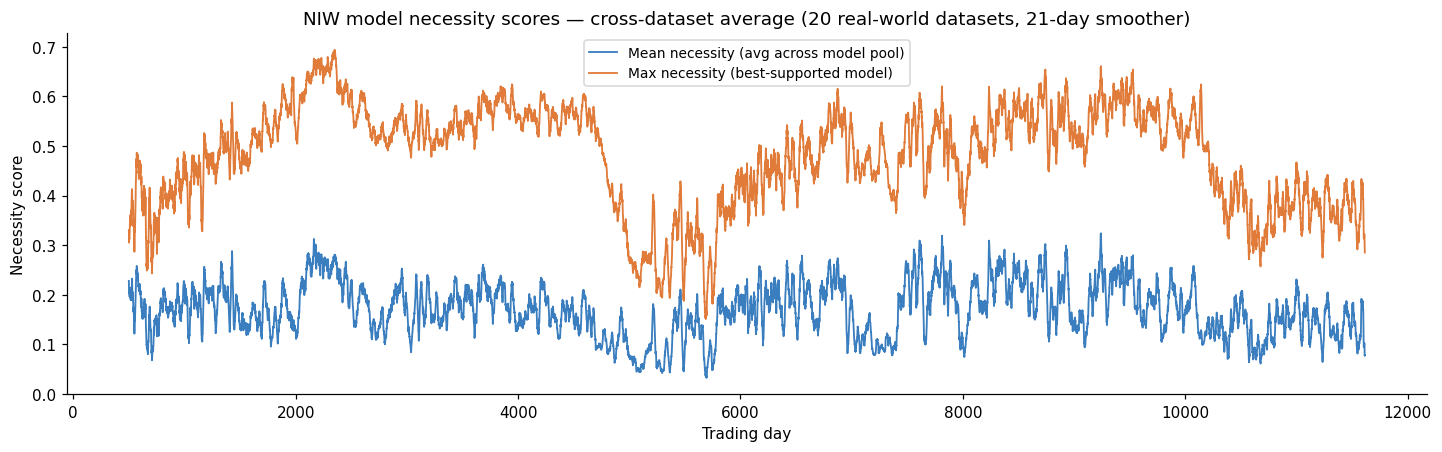

Avg mean necessity : 0.1702
Avg max  necessity : 0.4812


In [47]:
def smooth(x, w=21):
    return pd.Series(x).rolling(w, center=True, min_periods=1).mean().values

nec_mean_list, nec_max_list = [], []
t_index = None

for folder in real_folders:
    path = folder / 'possibilistic_diagnostics.csv'
    if not path.exists():
        continue
    diag = pd.read_csv(path).set_index('t')
    if t_index is None:
        t_index = diag.index.values
    nec_mean_list.append(diag['nec_mean'].values)
    nec_max_list.append(diag['nec_max'].values)

avg_nec_mean = np.nanmean(np.vstack(nec_mean_list), axis=0)
avg_nec_max  = np.nanmean(np.vstack(nec_max_list),  axis=0)

fig, ax = plt.subplots(figsize=(13, 4), constrained_layout=True)
ax.plot(t_index, smooth(avg_nec_mean, SMOOTH_WINDOW),
        color='#3a7ebf', lw=1.2, label='Mean necessity (avg across model pool)')
ax.plot(t_index, smooth(avg_nec_max, SMOOTH_WINDOW),
        color='#e07b39', lw=1.2, label='Max necessity (best-supported model)')
ax.set_ylabel('Necessity score')
ax.set_xlabel('Trading day')
ax.set_title(
    f'NIW model necessity scores — cross-dataset average '
    f'({len(nec_mean_list)} real-world datasets, {SMOOTH_WINDOW}-day smoother)'
)
ax.legend(fontsize=9, framealpha=0.8)
plt.show()

valid = ~np.isnan(avg_nec_mean)
print(f'Avg mean necessity : {avg_nec_mean[valid].mean():.4f}')
print(f'Avg max  necessity : {avg_nec_max[~np.isnan(avg_nec_max)].mean():.4f}')

---
## 5  Necessity-Based Weighting Schemes and Geometric Aggregation

The possibility scores $\pi_t(m)$ are converted to Markowitz-ready predictive moments via
two stages: (i) re-weighting by necessity, and (ii) geometric aggregation.

### Weighting Schemes

| Scheme | Weight $w_m$ | Behaviour |
|--------|-------------|----------|
| **Masked** | $\mathbf{1}[V_m > 0]$ / count | Hard threshold: include only models with positive necessity |
| **Power** | $V_m^\gamma / \sum_m V_m^\gamma$ | Soft concentration with parameter $\gamma > 0$ |
| **Exponential** | $\exp(-\eta(1-V_m)) / \sum_m \exp(\cdots)$ | Exponential penalty on low-validity models |

All three reduce to uniform averaging when all $V_m$ are equal, and concentrate weight
on high-validity models as discrimination increases.

### Geometric Aggregation

Given model NIW posteriors $(\mu_m, \kappa_m, \Delta_m, \nu_m)$ and weights $w_m$,
the aggregate mean and covariance are (equations B.30–B.32 of the paper):

$$\mu^\star = \frac{\sum_m w_m \kappa_m \mu_m}{\sum_m w_m \kappa_m},
\qquad \kappa^\star = \sum_m w_m \kappa_m$$

$$\hat{\Sigma}^\star = \frac{\Delta^\star}{\nu^\star},
\qquad \nu^\star = \sum_m w_m \nu_m$$

$$\Delta^\star = \sum_m w_m \bigl(\Delta_m + \kappa_m \mu_m \mu_m^\top\bigr)
- \kappa^\star \mu^\star {\mu^\star}^\top$$

The mean $\mu^\star$ is a precision-weighted average across models.
The covariance $\hat{\Sigma}^\star$ combines each model's scale matrix $\Delta_m$ with
a within-model mean outer product, then corrects for the aggregate mean — capturing
both within-model uncertainty and cross-model dispersion.


---
## 6  Predictive Distribution Performance

Before examining portfolio outcomes, we assess how well each algorithm tracks the true
return distribution day-by-day, using two scoring rules:

- **Log-likelihood** ($\uparrow$ better): $\log p(x_t \mid \hat{\theta}_{t-1})$ under the NIW Student-$t$ predictive
- **Mahalanobis distance** ($\downarrow$ better): $(x_t - \hat{\mu}_{t-1})^\top \hat{\Sigma}_{t-1}^{-1} (x_t - \hat{\mu}_{t-1})$

We notice that the possibilistic predictives are better consistently in the log-likelihoods, but perform comparably in the Mahalanobis distance. This could be explained by the fact that the BMA predictive over-inflates the covariance, thereby mechanically deflating $\hat{\Sigma}^{-1}$, resulting in a lower Mahalanobis distance.

Results are averaged across all 20 real-world datasets.

In [48]:
def rolling_logdet(arr, window):
    T, n = arr.shape
    result = np.full(T, np.nan)
    for t in range(window - 1, T):
        cov = np.cov(arr[t - window + 1 : t + 1].T, ddof=1)
        sign, ld = np.linalg.slogdet(cov)
        result[t] = ld if sign > 0 else np.nan
    return result

def load_predictive(folder, stem):
    mu_p  = folder / f'{stem}_mus.npy'
    sig_p = folder / f'{stem}_sigmas.npy'
    if mu_p.exists() and sig_p.exists():
        return np.load(mu_p), np.load(sig_p)
    return None, None

def get_ts(folder, kind, stem):
    path = folder / f'{kind}.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path, index_col=0)
    return df[stem].values.astype(float) if stem in df.columns else None

def avg_over(fn, folders):
    series = [s for f in folders if (s := fn(f)) is not None]
    return np.nanmean(np.vstack(series), axis=0) if series else None

def portfolio_rets(folder, stem):
    ret = pd.read_csv(folder / 'returns.csv', index_col=0).values
    w_path = folder / f'{stem}_weights.csv'
    if not w_path.exists():
        return None
    wts = pd.read_csv(w_path, index_col=0).values
    port = np.full(len(ret), np.nan)
    for i in range(1, len(ret)):
        if np.isfinite(wts[i - 1]).all():
            port[i] = float(wts[i - 1] @ ret[i])
    return port

/var/folders/dg/fjbjk5rn15jc36w_2kg97pfh0000gn/T/ipykernel_19530/532164863.py:26: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.vstack(series), axis=0) if series else None


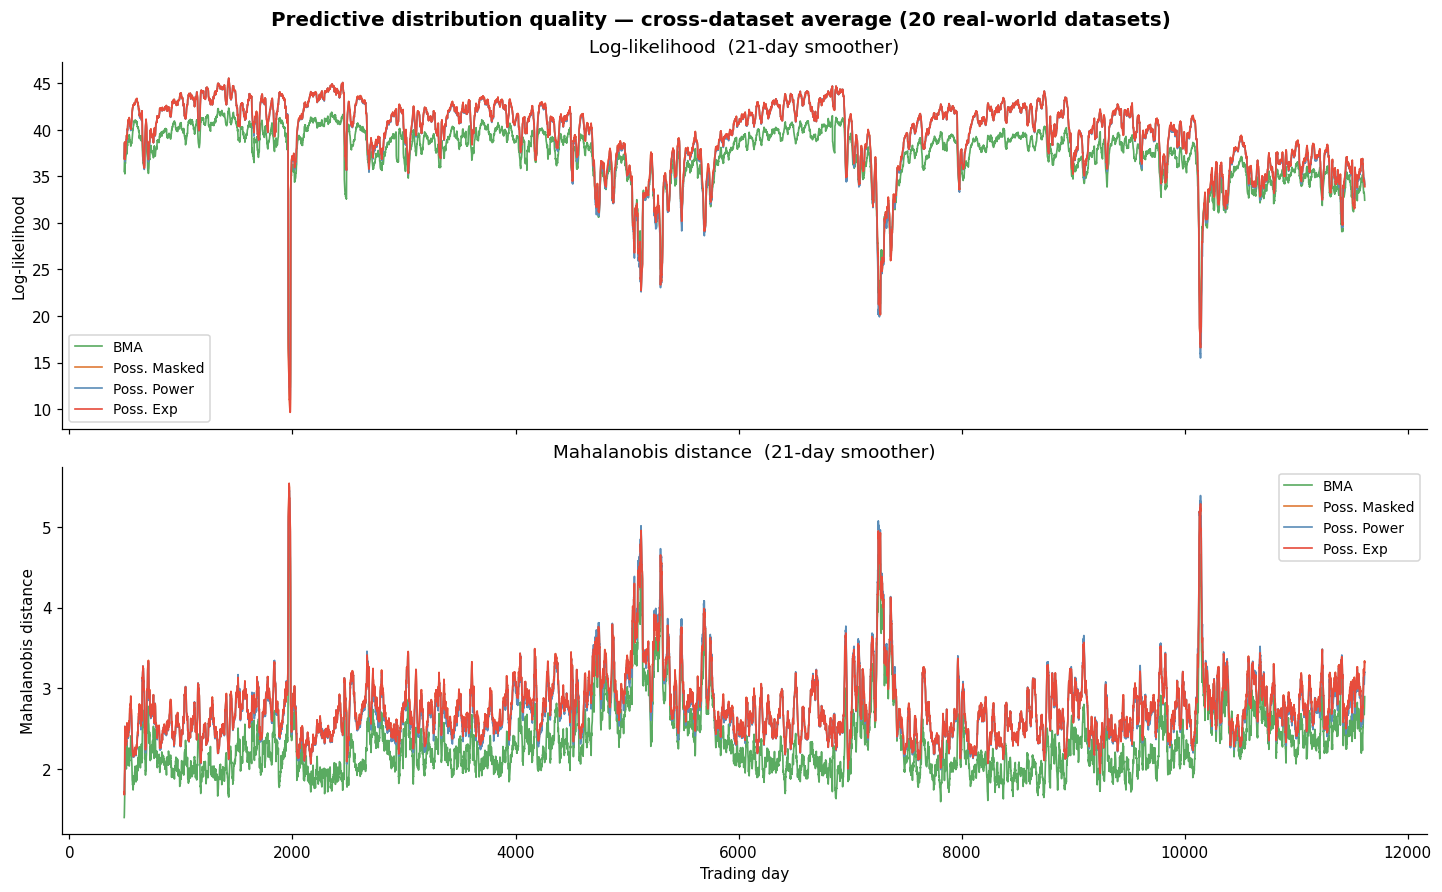

In [49]:
fig, (ax_ll, ax_mah) = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
fig.suptitle(
    'Predictive distribution quality — cross-dataset average (20 real-world datasets)',
    fontsize=13, fontweight='bold'
)

for stem in MODEL_STEMS:
    label = STRATEGY_LABELS[stem]
    color = MODEL_COLORS[stem]
    ll  = avg_over(lambda f, s=stem: get_ts(f, 'log_likelihood', s), real_folders)
    mah = avg_over(lambda f, s=stem: get_ts(f, 'mahalanobis', s),   real_folders)
    if ll  is not None: ax_ll.plot( smooth(ll,  SMOOTH_WINDOW), color=color, lw=1.1, label=label)
    if mah is not None: ax_mah.plot(smooth(mah, SMOOTH_WINDOW), color=color, lw=1.1, label=label)

ax_ll.set_ylabel('Log-likelihood')
ax_ll.set_title(f'Log-likelihood  ({SMOOTH_WINDOW}-day smoother)')
ax_ll.legend(fontsize=9, framealpha=0.8)
ax_ll.tick_params(labelbottom=False)

ax_mah.set_ylabel('Mahalanobis distance')
ax_mah.set_xlabel('Trading day')
ax_mah.set_title(f'Mahalanobis distance  ({SMOOTH_WINDOW}-day smoother)')
ax_mah.legend(fontsize=9, framealpha=0.8)
plt.show()

We can see that the likelihood of the predicted moments by the possibilistic methods are consistently greater than the BMA benchmark. The Mahalnobis distance is not quite the same, but that can be explained by the inflated covariance estimates of BMA.

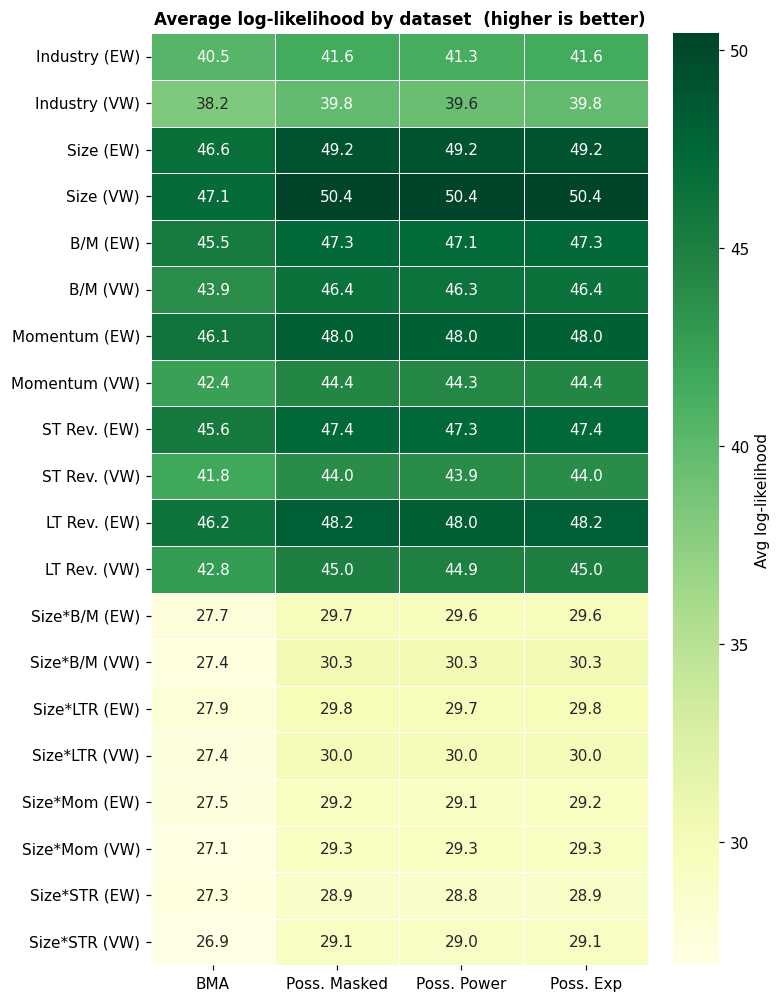

Cross-dataset mean avg log-likelihood:
BMA             37.29
Poss. Masked    39.40
Poss. Power     39.31
Poss. Exp       39.40


In [50]:
rows_ll = {}
for folder in real_folders:
    dname = DATASET_LABELS.get(folder.name, folder.name)
    row = {}
    for stem in MODEL_STEMS:
        s = get_ts(folder, 'log_likelihood', stem)
        if s is not None:
            row[STRATEGY_LABELS[stem]] = np.nanmean(s)
    if row:
        rows_ll[dname] = row

heat_ll = pd.DataFrame(rows_ll).T
fig, ax = plt.subplots(figsize=(7, 9), constrained_layout=True)
sns.heatmap(heat_ll, annot=True, fmt='.1f', cmap='YlGn', ax=ax,
            linewidths=0.4, cbar_kws={'label': 'Avg log-likelihood'})
ax.set_title('Average log-likelihood by dataset  (higher is better)',
             fontsize=11, fontweight='bold')
plt.show()

print('Cross-dataset mean avg log-likelihood:')
print(heat_ll.mean().round(2).to_string())

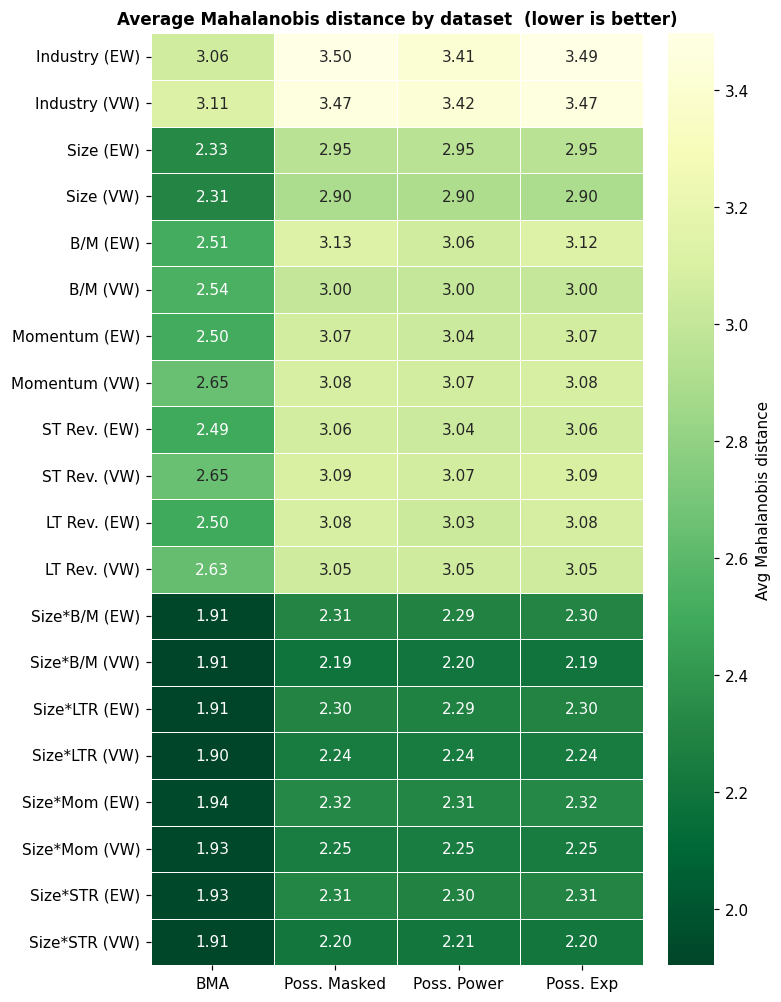

Cross-dataset mean avg Mahalanobis distance:
BMA             2.330
Poss. Masked    2.775
Poss. Power     2.756
Poss. Exp       2.774


In [65]:
rows_mah = {}
for folder in real_folders:
    dname = DATASET_LABELS.get(folder.name, folder.name)
    row = {}
    for stem in MODEL_STEMS:
        s = get_ts(folder, 'mahalanobis', stem)
        if s is not None:
            row[STRATEGY_LABELS[stem]] = np.nanmean(s)
    if row:
        rows_mah[dname] = row

heat_mah = pd.DataFrame(rows_mah).T
fig, ax = plt.subplots(figsize=(7, 9), constrained_layout=True)
sns.heatmap(heat_mah, annot=True, fmt='.2f', cmap='YlGn_r', ax=ax,
            linewidths=0.4, cbar_kws={'label': 'Avg Mahalanobis distance'})
ax.set_title('Average Mahalanobis distance by dataset  (lower is better)',
             fontsize=11, fontweight='bold')
plt.show()

print('Cross-dataset mean avg Mahalanobis distance:')
print(heat_mah.mean().round(3).to_string())

/var/folders/dg/fjbjk5rn15jc36w_2kg97pfh0000gn/T/ipykernel_19530/532164863.py:26: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.vstack(series), axis=0) if series else None
/Users/jaini/possibilistic-portfolio-optimisation-py/dev/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


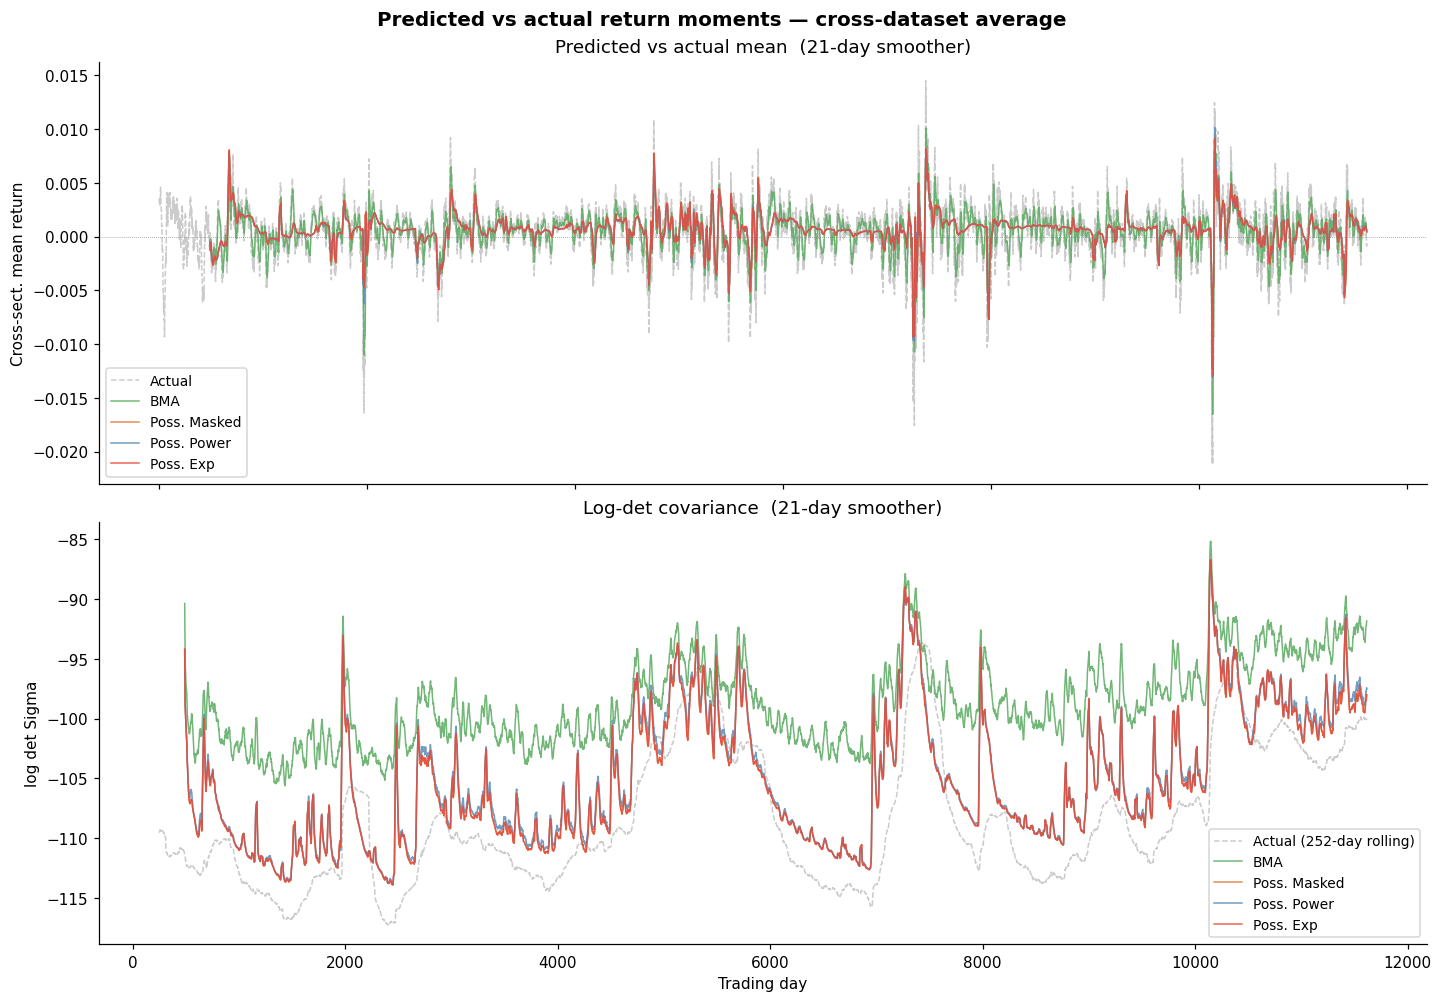

In [52]:
fig, (ax_mean, ax_cov) = plt.subplots(2, 1, figsize=(13, 9), constrained_layout=True)
fig.suptitle('Predicted vs actual return moments — cross-dataset average',
             fontsize=13, fontweight='bold')

actual_means = avg_over(
    lambda f: pd.read_csv(f / 'returns.csv', index_col=0).values.mean(axis=1), real_folders)
actual_ld    = avg_over(
    lambda f: rolling_logdet(pd.read_csv(f / 'returns.csv', index_col=0).values, COV_WINDOW),
    real_folders)

ax_mean.plot(smooth(actual_means, SMOOTH_WINDOW), **ACTUAL_STYLE, label='Actual')
ax_cov.plot(actual_ld, **ACTUAL_STYLE, label=f'Actual ({COV_WINDOW}-day rolling)')

for stem in MODEL_STEMS:
    label = STRATEGY_LABELS[stem]
    color = MODEL_COLORS[stem]

    def _mean(f, s=stem):
        p = f / f'{s}_mus.npy'
        return np.load(p).mean(axis=1) if p.exists() else None

    def _ld(f, s=stem):
        p = f / f'{s}_sigmas.npy'
        if not p.exists(): return None
        _, ld = np.linalg.slogdet(np.load(p))
        return ld.astype(float)

    mean_avg = avg_over(_mean, real_folders)
    ld_avg   = avg_over(_ld,   real_folders)
    if mean_avg is not None:
        ax_mean.plot(smooth(mean_avg, SMOOTH_WINDOW), color=color, lw=1.0, alpha=0.85, label=label)
    if ld_avg is not None:
        ax_cov.plot(smooth(ld_avg, SMOOTH_WINDOW),   color=color, lw=1.0, alpha=0.85, label=label)

ax_mean.axhline(0, color='grey', lw=0.5, ls=':')
ax_mean.set_ylabel('Cross-sect. mean return')
ax_mean.set_title(f'Predicted vs actual mean  ({SMOOTH_WINDOW}-day smoother)')
ax_mean.legend(fontsize=9, framealpha=0.8)
ax_mean.tick_params(labelbottom=False)

ax_cov.set_ylabel('log det Sigma')
ax_cov.set_xlabel('Trading day')
ax_cov.set_title(f'Log-det covariance  ({SMOOTH_WINDOW}-day smoother)')
ax_cov.legend(fontsize=9, framealpha=0.8)
plt.show()

We see that the mean predicted by the possibilistic methods is much more smooth than the one predicted by the BMA method. This is both due to (a) the inherent smoothness in the possibilistic method imposed by internal validity (b) heightened volatility in the BMA due to the perfect sharing prior.

---
## 7  Unconstrained Portfolio Results

Portfolio weights are derived from $(\hat{\mu}_t, \hat{\Sigma}_t)$ via mean-variance optimisation,
allowing both long and short positions. Evaluated over 1980–2025 (~11,600 trading days).

**Key expected trade-off** (from the paper): possibilistic methods reduce average turnover by
~50% relative to BMA at a Sharpe cost of ~6.7%. The smoother possibilistic predictives produce
more stable weights that rebalance less aggressively.

In [57]:
METRICS = ['sharpe', 'avg_turnover', 'avg_log_likelihood']
METRIC_LABELS = {
    'sharpe':             'Sharpe ratio',
    'avg_turnover':       'Avg daily turnover',
    'avg_log_likelihood': 'Avg log-likelihood',
}

def build_metric_table(metric, stems, label_map):
    rows = {}
    for folder in real_folders:
        dname = DATASET_LABELS.get(folder.name, folder.name)
        if folder.name not in all_scalars:
            continue
        df = all_scalars[folder.name]
        row = {label_map.get(s, s): df.loc[s, metric]
               for s in stems if s in df.index and metric in df.columns}
        if row:
            rows[dname] = row
    return pd.DataFrame(rows).T if rows else None

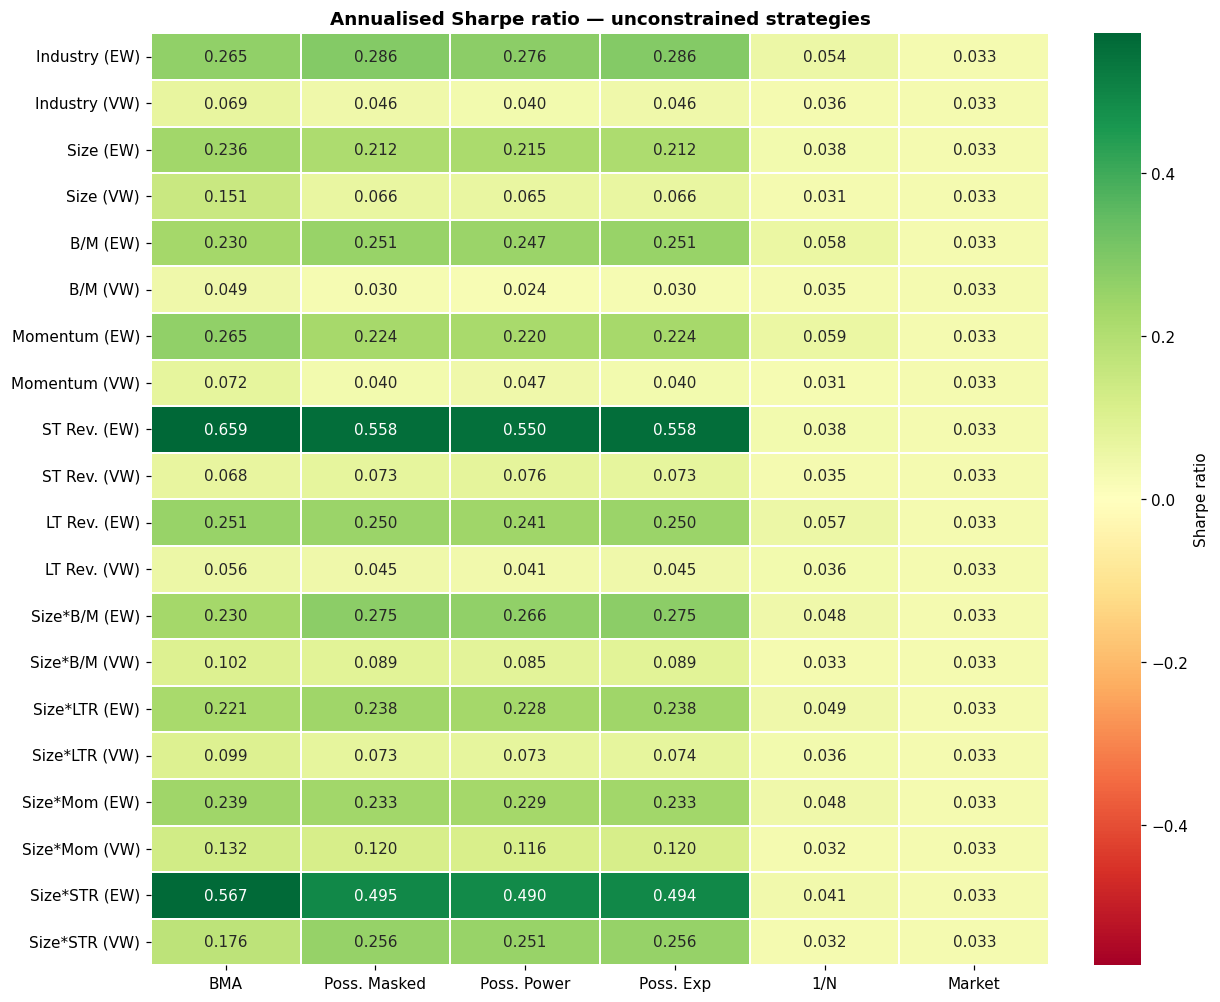

Cross-dataset mean Sharpe:
BMA             0.2068
Poss. Masked    0.1930
Poss. Power     0.1890
Poss. Exp       0.1930
1/N             0.0413
Market          0.0330


In [58]:
tbl_sharpe = build_metric_table('sharpe', FOCUS_STEMS, STRATEGY_LABELS)
col_order  = [STRATEGY_LABELS[s] for s in FOCUS_STEMS if STRATEGY_LABELS[s] in tbl_sharpe.columns]
tbl_sharpe = tbl_sharpe[col_order]

vmax = tbl_sharpe.abs().quantile(0.95).max()
fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
sns.heatmap(tbl_sharpe, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-vmax, vmax=vmax, ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Sharpe ratio'})
ax.set_title('Annualised Sharpe ratio — unconstrained strategies',
             fontsize=12, fontweight='bold')
plt.show()

print('Cross-dataset mean Sharpe:')
print(tbl_sharpe.mean().round(4).to_string())

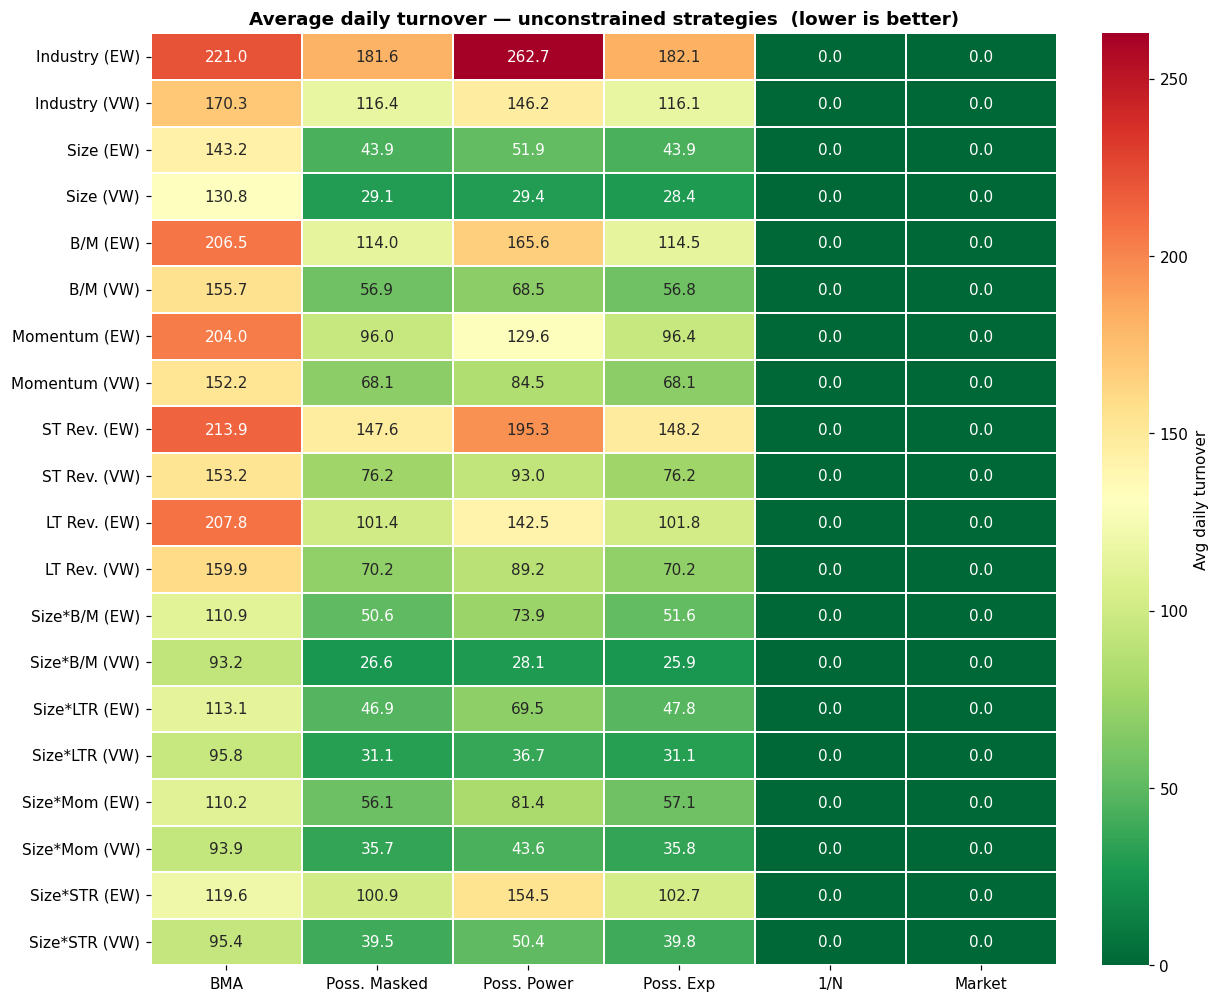

Cross-dataset mean avg turnover:
BMA             147.5
Poss. Masked     74.4
Poss. Power      99.8
Poss. Exp        74.7
1/N               0.0
Market            0.0


In [ ]:
tbl_to = build_metric_table('avg_turnover', FOCUS_STEMS, STRATEGY_LABELS)[col_order]

fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
sns.heatmap(tbl_to, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Avg daily turnover'})
ax.set_title('Average daily turnover — unconstrained strategies  (lower is better)',
             fontsize=12, fontweight='bold')
plt.show()

print('Cross-dataset mean avg turnover:')
print(tbl_to.mean().round(1).to_string())

/var/folders/dg/fjbjk5rn15jc36w_2kg97pfh0000gn/T/ipykernel_19530/4168230790.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_4, patch_artist=True,
/var/folders/dg/fjbjk5rn15jc36w_2kg97pfh0000gn/T/ipykernel_19530/4168230790.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_4, patch_artist=True,


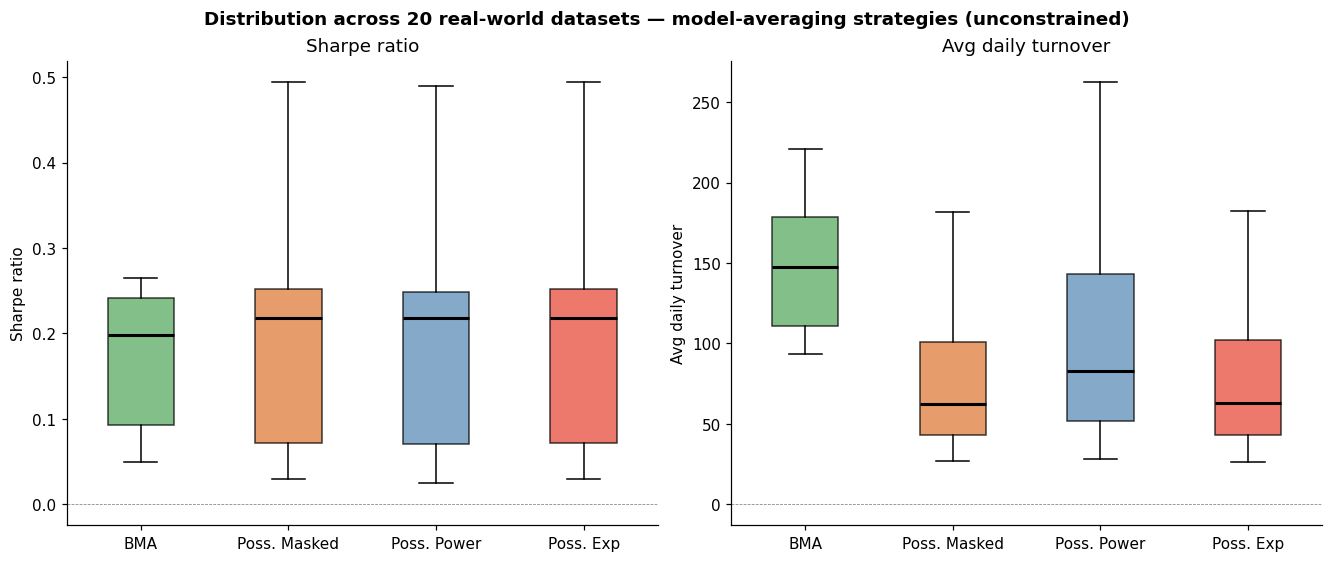

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle(
    'Distribution across 20 real-world datasets — model-averaging strategies (unconstrained)',
    fontsize=12, fontweight='bold'
)

labels_4 = [STRATEGY_LABELS[s] for s in MODEL_STEMS]

for ax, metric, ylabel in [
    (axes[0], 'sharpe',       'Sharpe ratio'),
    (axes[1], 'avg_turnover', 'Avg daily turnover'),
]:
    data = []
    for stem in MODEL_STEMS:
        vals = [
            all_scalars[f.name].loc[stem, metric]
            for f in real_folders
            if f.name in all_scalars
            and stem in all_scalars[f.name].index
            and metric in all_scalars[f.name].columns
        ]
        data.append(vals)
    bp = ax.boxplot(data, labels=labels_4, patch_artist=True,
                    medianprops={'color': 'black', 'lw': 2}, showfliers=False)
    for patch, color in zip(bp['boxes'], MODEL_COLOR_LIST):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_title(ylabel)
    ax.set_ylabel(ylabel)
plt.show()

---
## 8  Long-Only (Constrained) Portfolio Results

Long-only portfolios restrict all weights to $w_i \geq 0$. This constraint substantially
reduces turnover for all strategies (since weights are bounded within $[0, 1]$) but
also limits the ability to exploit short-term expected return signals.

**Key result from the paper**: the possibilistic framework achieves a **~69% turnover
reduction** relative to BMA under the long-only constraint (vs ~50% unconstrained),
at a Sharpe cost of only **~3.4%** (vs ~6.7% unconstrained). The conservatism of
possibilistic weights is especially effective when extreme position swings are disallowed.

In [61]:
LO_STEMS = [s + '_longonly' for s in FOCUS_STEMS]
LO_LABELS = {s + '_longonly': STRATEGY_LABELS[s] for s in FOCUS_STEMS}    

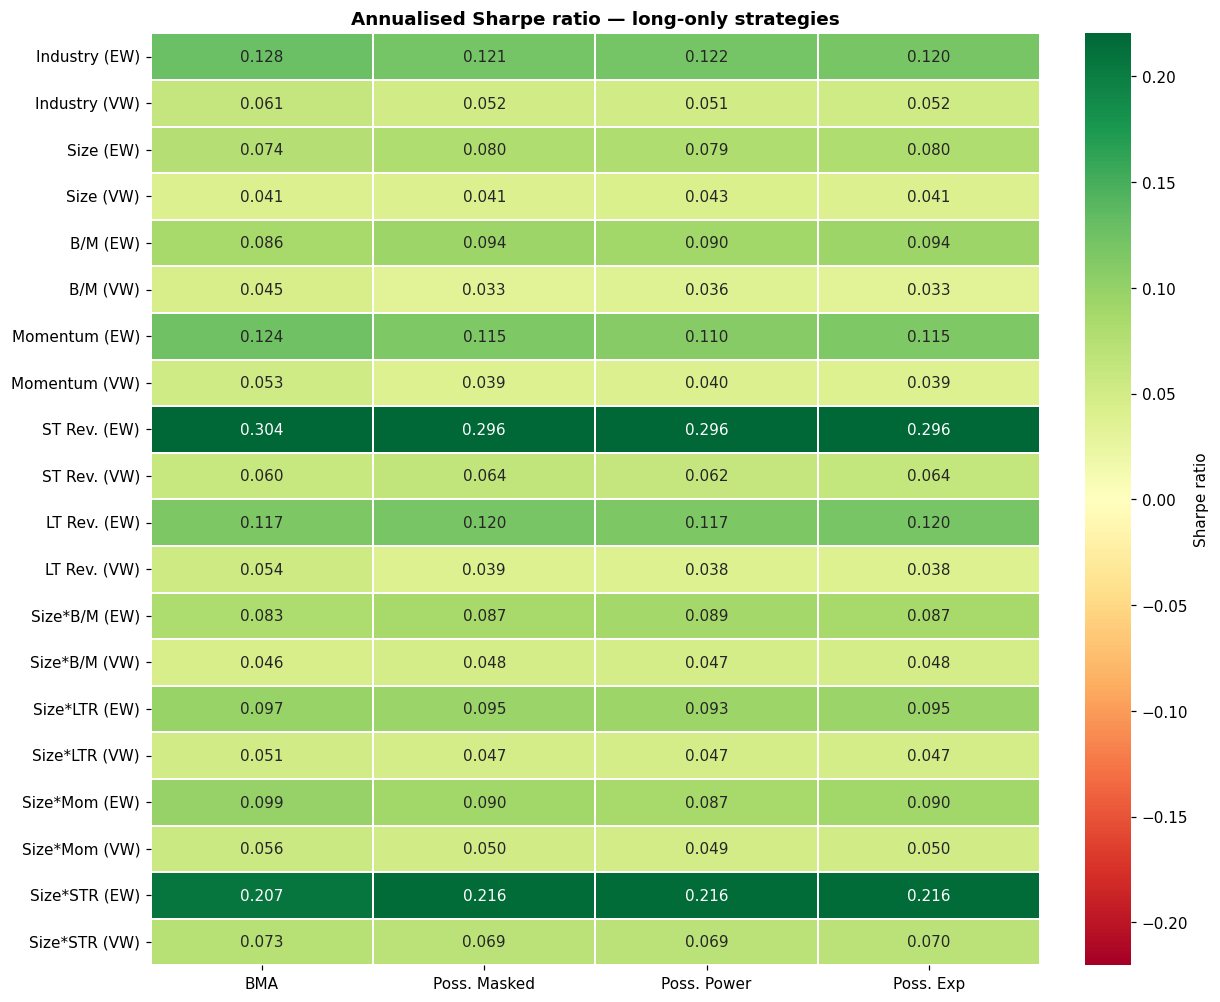

Cross-dataset mean Sharpe (long-only):
BMA             0.0930
Poss. Masked    0.0898
Poss. Power     0.0891
Poss. Exp       0.0899


In [62]:
tbl_sharpe_lo = build_metric_table('sharpe', LO_STEMS, LO_LABELS)
col_order_lo  = [LO_LABELS[s] for s in LO_STEMS if LO_LABELS[s] in tbl_sharpe_lo.columns]
tbl_sharpe_lo = tbl_sharpe_lo[col_order_lo]

vmax_lo = tbl_sharpe_lo.abs().quantile(0.95).max()
fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
sns.heatmap(tbl_sharpe_lo, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-vmax_lo, vmax=vmax_lo, ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Sharpe ratio'})
ax.set_title('Annualised Sharpe ratio — long-only strategies',
             fontsize=12, fontweight='bold')
plt.show()

print('Cross-dataset mean Sharpe (long-only):')
print(tbl_sharpe_lo.mean().round(4).to_string())

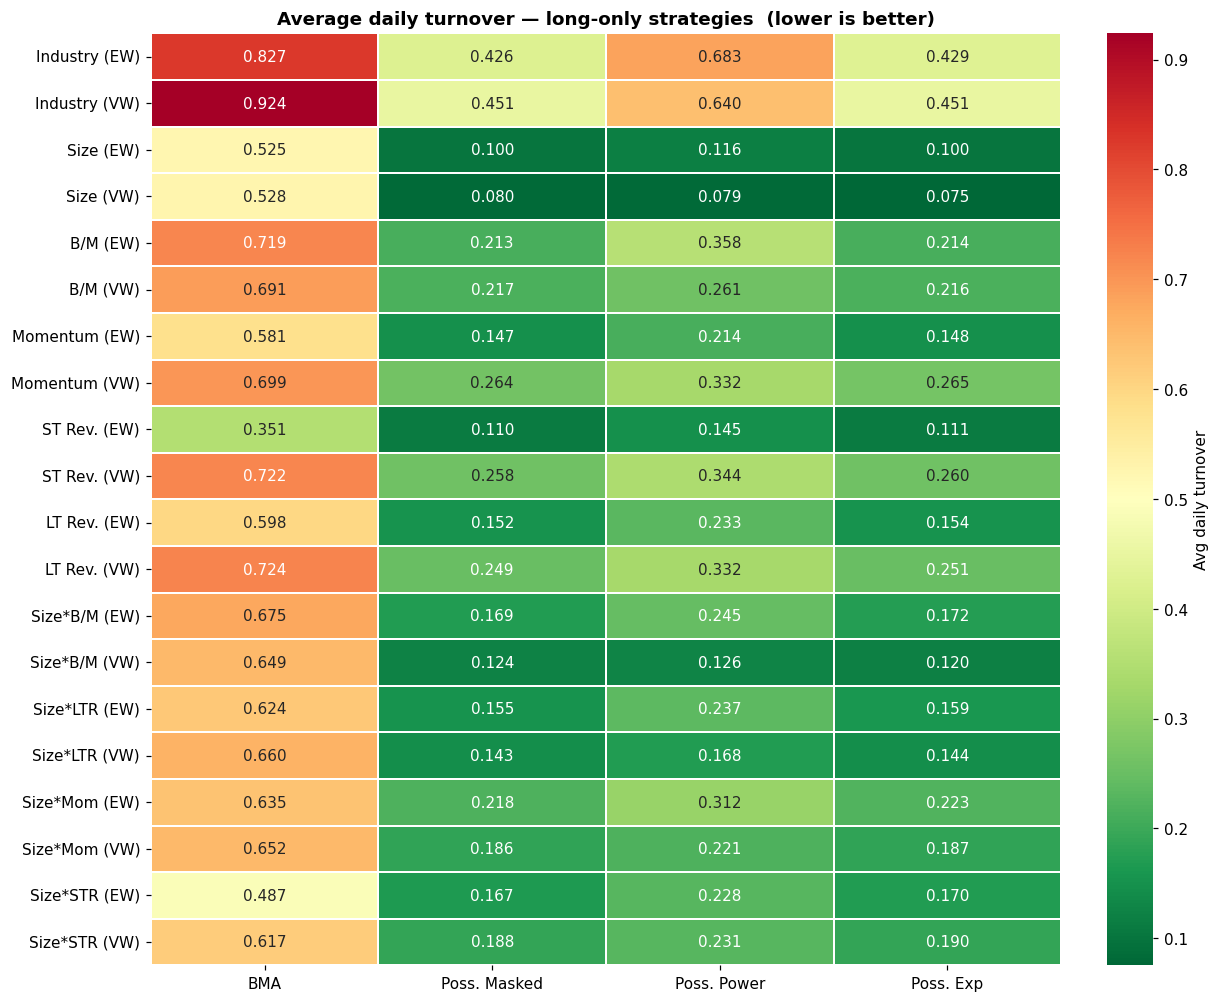

Cross-dataset mean avg turnover (long-only):
BMA             0.6444
Poss. Masked    0.2008
Poss. Power     0.2753
Poss. Exp       0.2020


In [66]:
tbl_to_lo = build_metric_table('avg_turnover', LO_STEMS, LO_LABELS)[col_order_lo]

fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
sns.heatmap(tbl_to_lo, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Avg daily turnover'})
ax.set_title('Average daily turnover — long-only strategies  (lower is better)',
             fontsize=12, fontweight='bold')
plt.show()

print('Cross-dataset mean avg turnover (long-only):')
print(tbl_to_lo.mean().round(4).to_string())

/var/folders/dg/fjbjk5rn15jc36w_2kg97pfh0000gn/T/ipykernel_19530/610412130.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_4, patch_artist=True,
/var/folders/dg/fjbjk5rn15jc36w_2kg97pfh0000gn/T/ipykernel_19530/610412130.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_4, patch_artist=True,


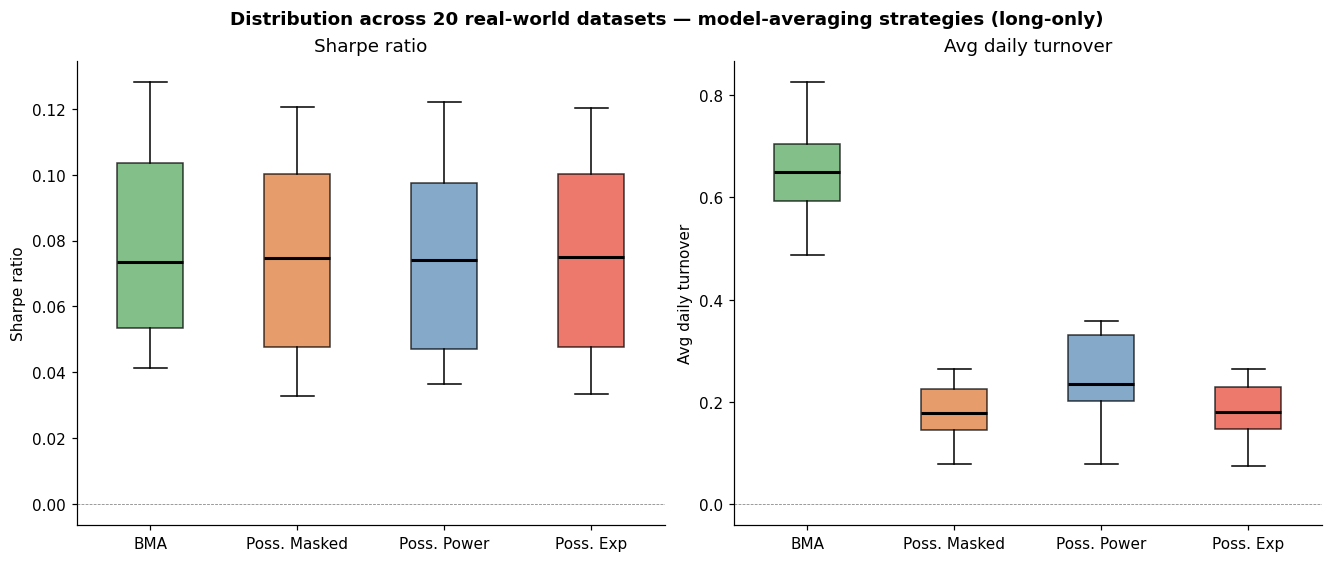

In [64]:
MODEL_STEMS_LO = [s + '_longonly' for s in MODEL_STEMS]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle(
    'Distribution across 20 real-world datasets — model-averaging strategies (long-only)',
    fontsize=12, fontweight='bold'
)

for ax, metric, ylabel in [
    (axes[0], 'sharpe',       'Sharpe ratio'),
    (axes[1], 'avg_turnover', 'Avg daily turnover'),
]:
    data = []
    for stem in MODEL_STEMS_LO:
        vals = [
            all_scalars[f.name].loc[stem, metric]
            for f in real_folders
            if f.name in all_scalars
            and stem in all_scalars[f.name].index
            and metric in all_scalars[f.name].columns
        ]
        data.append(vals)
    bp = ax.boxplot(data, labels=labels_4, patch_artist=True,
                    medianprops={'color': 'black', 'lw': 2}, showfliers=False)
    for patch, color in zip(bp['boxes'], MODEL_COLOR_LIST):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_title(ylabel)
    ax.set_ylabel(ylabel)
plt.show()